# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.605170,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-2.302585,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,2.302585,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,4.605170,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40380629,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,-4.605170,5.302966e+06,745.206312,0.299362,0.253855,4.534481,0.0,20.0,20.0000,-6.8880,0.011809,0.487632,0.000221,6.028153e+06,3.349485,2.651569,0.000086,0.000373
40380759,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,-2.302585,5.302938e+06,878.007541,0.337113,0.287861,4.533714,0.0,20.0,20.0000,-2.7856,0.011809,0.487630,0.000260,6.028179e+06,3.349485,2.651569,0.000100,0.000439
40380889,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,0.000000,5.302296e+06,3574.598859,0.595004,0.473720,4.222655,0.0,20.0,20.0000,-8.6832,0.011807,0.487587,0.001055,6.028769e+06,3.349485,2.651569,0.000421,0.001787
40381019,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,2.302585,5.281215e+06,80956.168445,1.719760,0.567011,1.675535,0.0,20.0,4.5040,-11.2800,0.011733,0.486155,0.022329,6.048124e+06,3.349485,2.651569,0.010961,0.040478


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

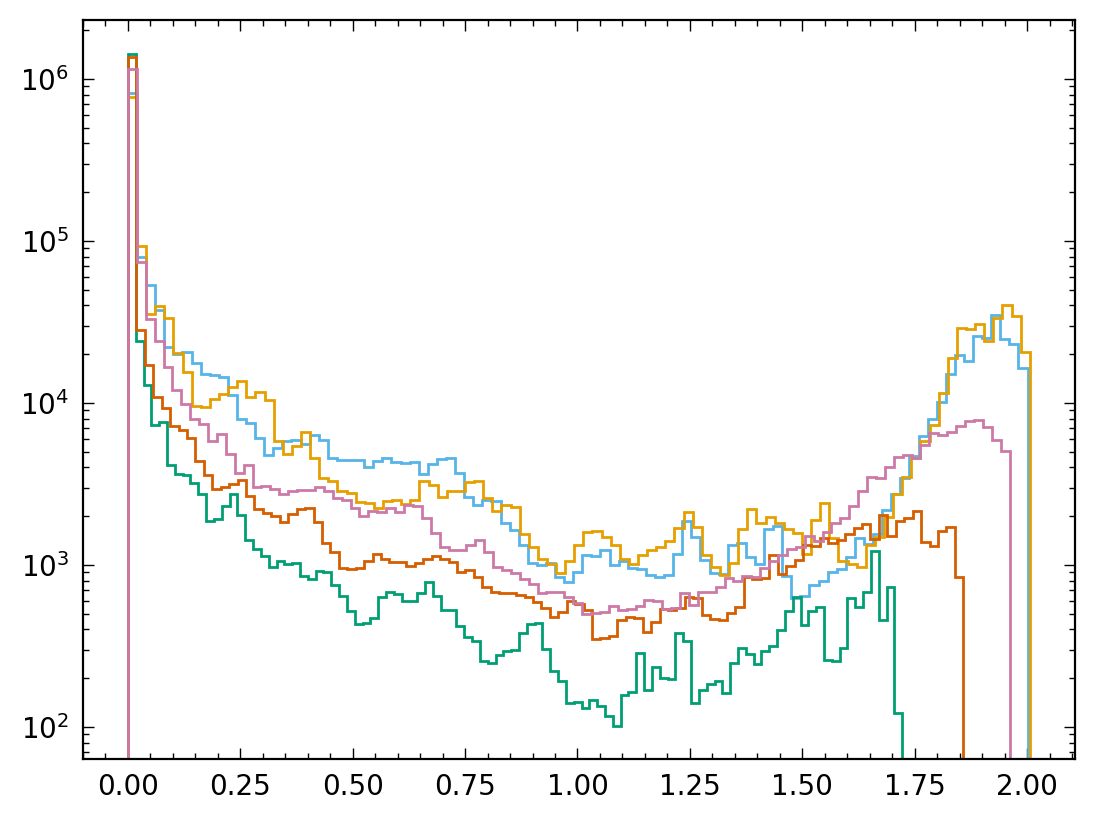

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-26.795884,0.658679,0.411624,0.118998
1,-6.698971,1.257203,0.393141,0.135393
2,0.700124,0.088084,0.492526,0.027241
3,0.717337,0.117737,0.570822,0.036247
4,0.735609,0.145725,0.623572,0.044298
...,...,...,...,...
100,2.677607,1.992929,0.686155,0.094745
101,2.813581,2.131871,0.691064,0.106263
102,3.349485,0.011641,0.483135,0.032169
103,5.359177,0.060422,0.475338,0.042110


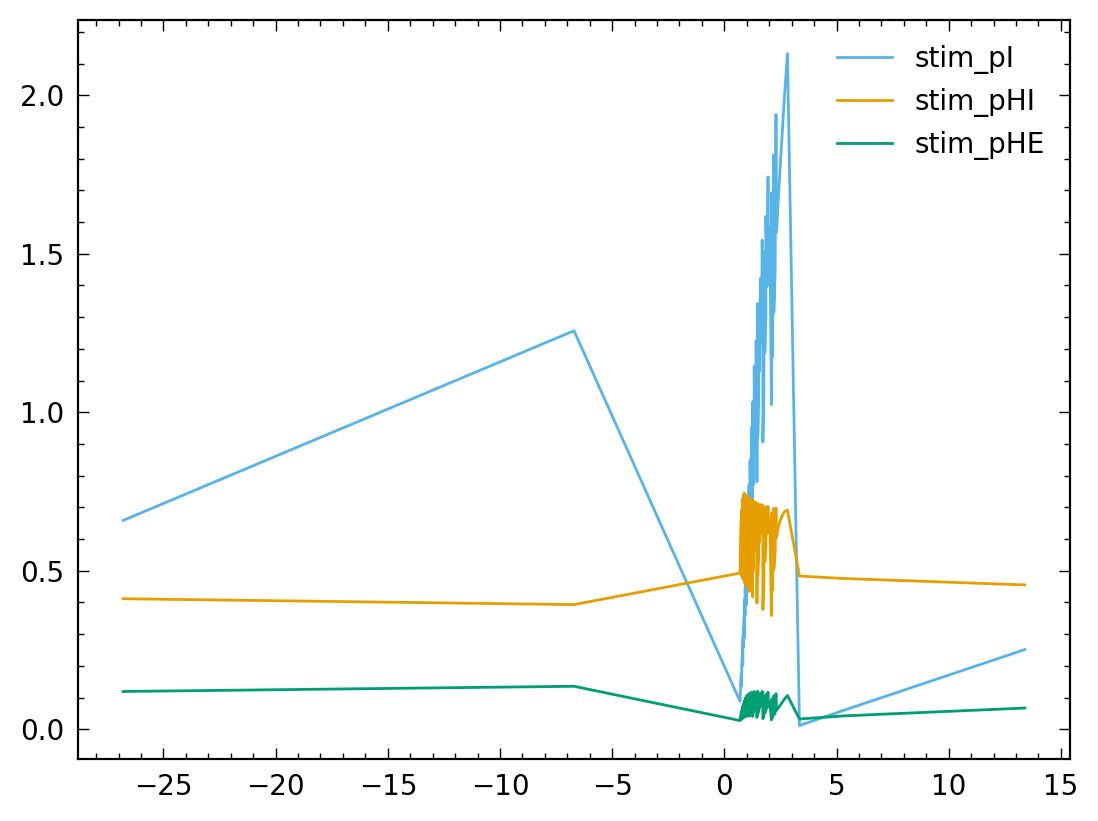

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 12
fevals: 12
fevals: 10
fevals: 11


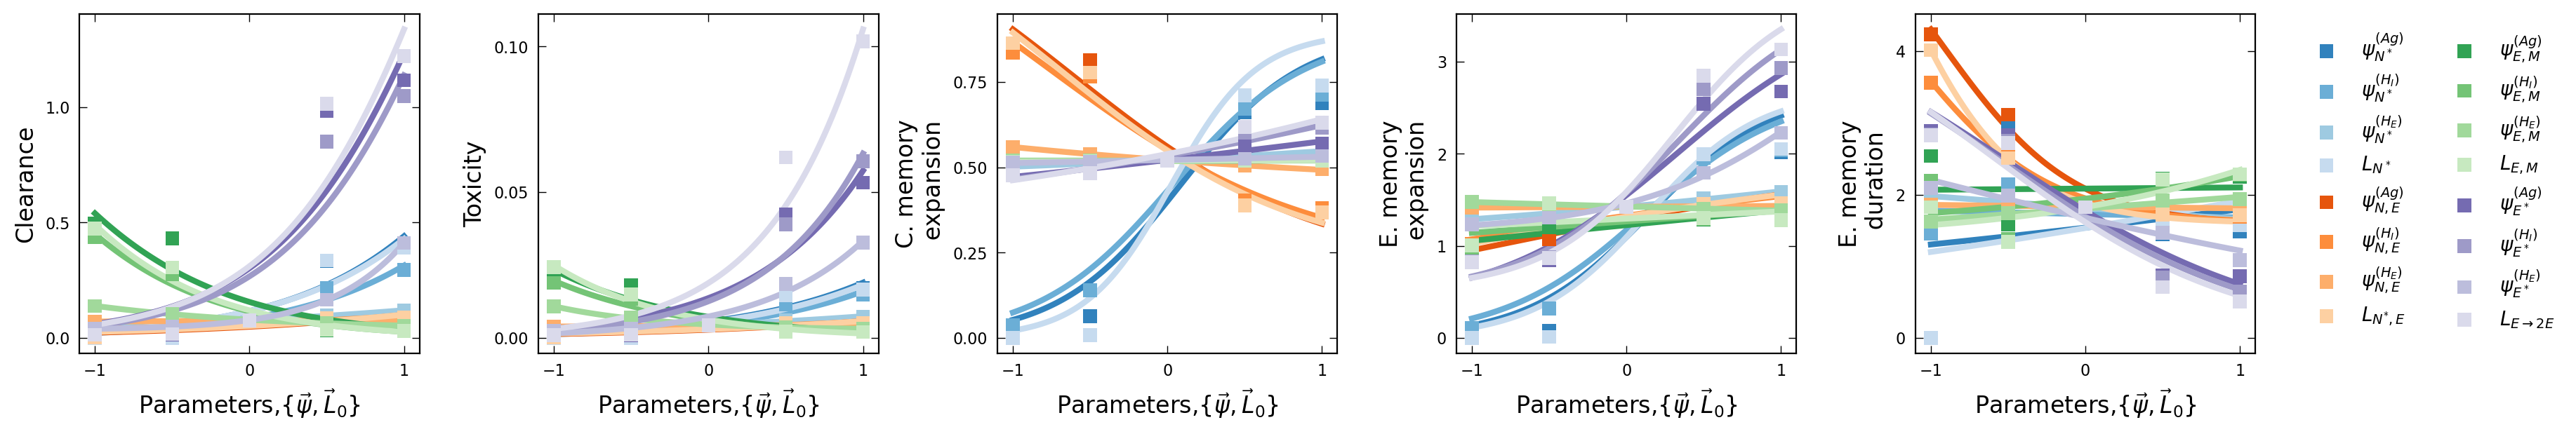

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    data = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[zero_regs]), axis = 1) == 0.0)]
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.loc[(np.sum(np.abs(data[reg_choice]), axis = 1) == np.abs(data[reg_choice[j]]))].groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
# del data

fevals: 9
fevals: 13
fevals: 10
fevals: 17


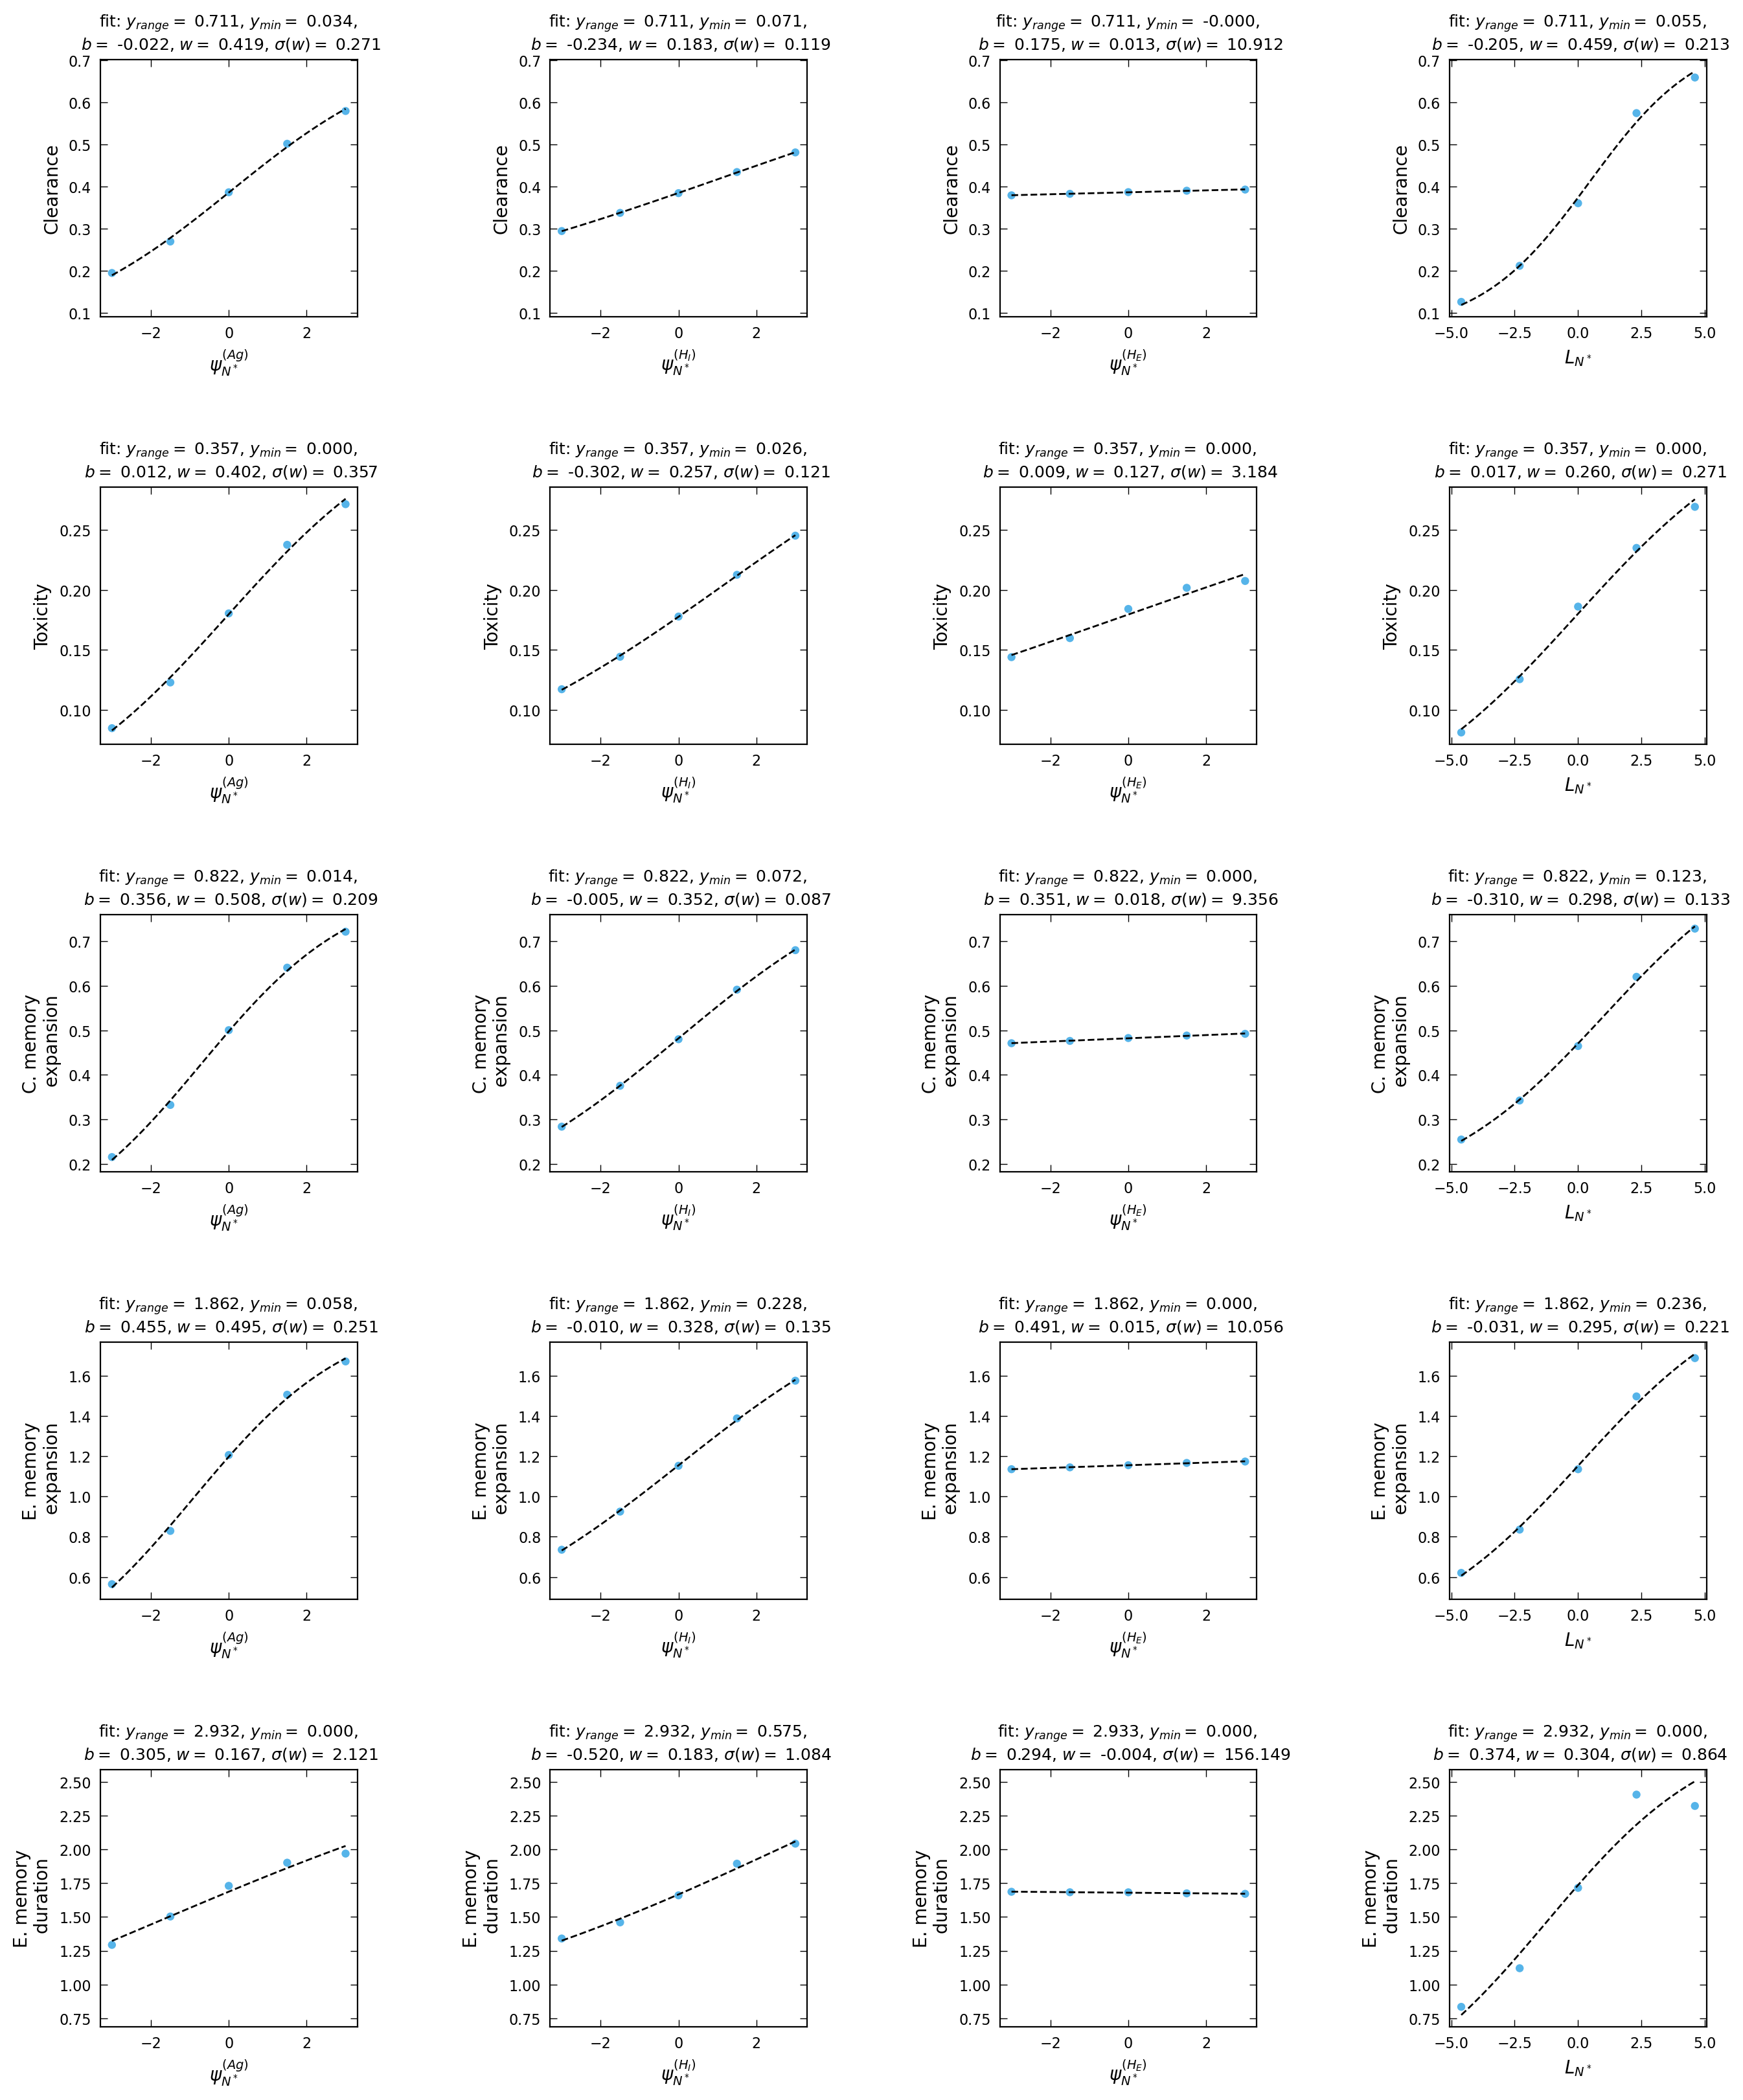

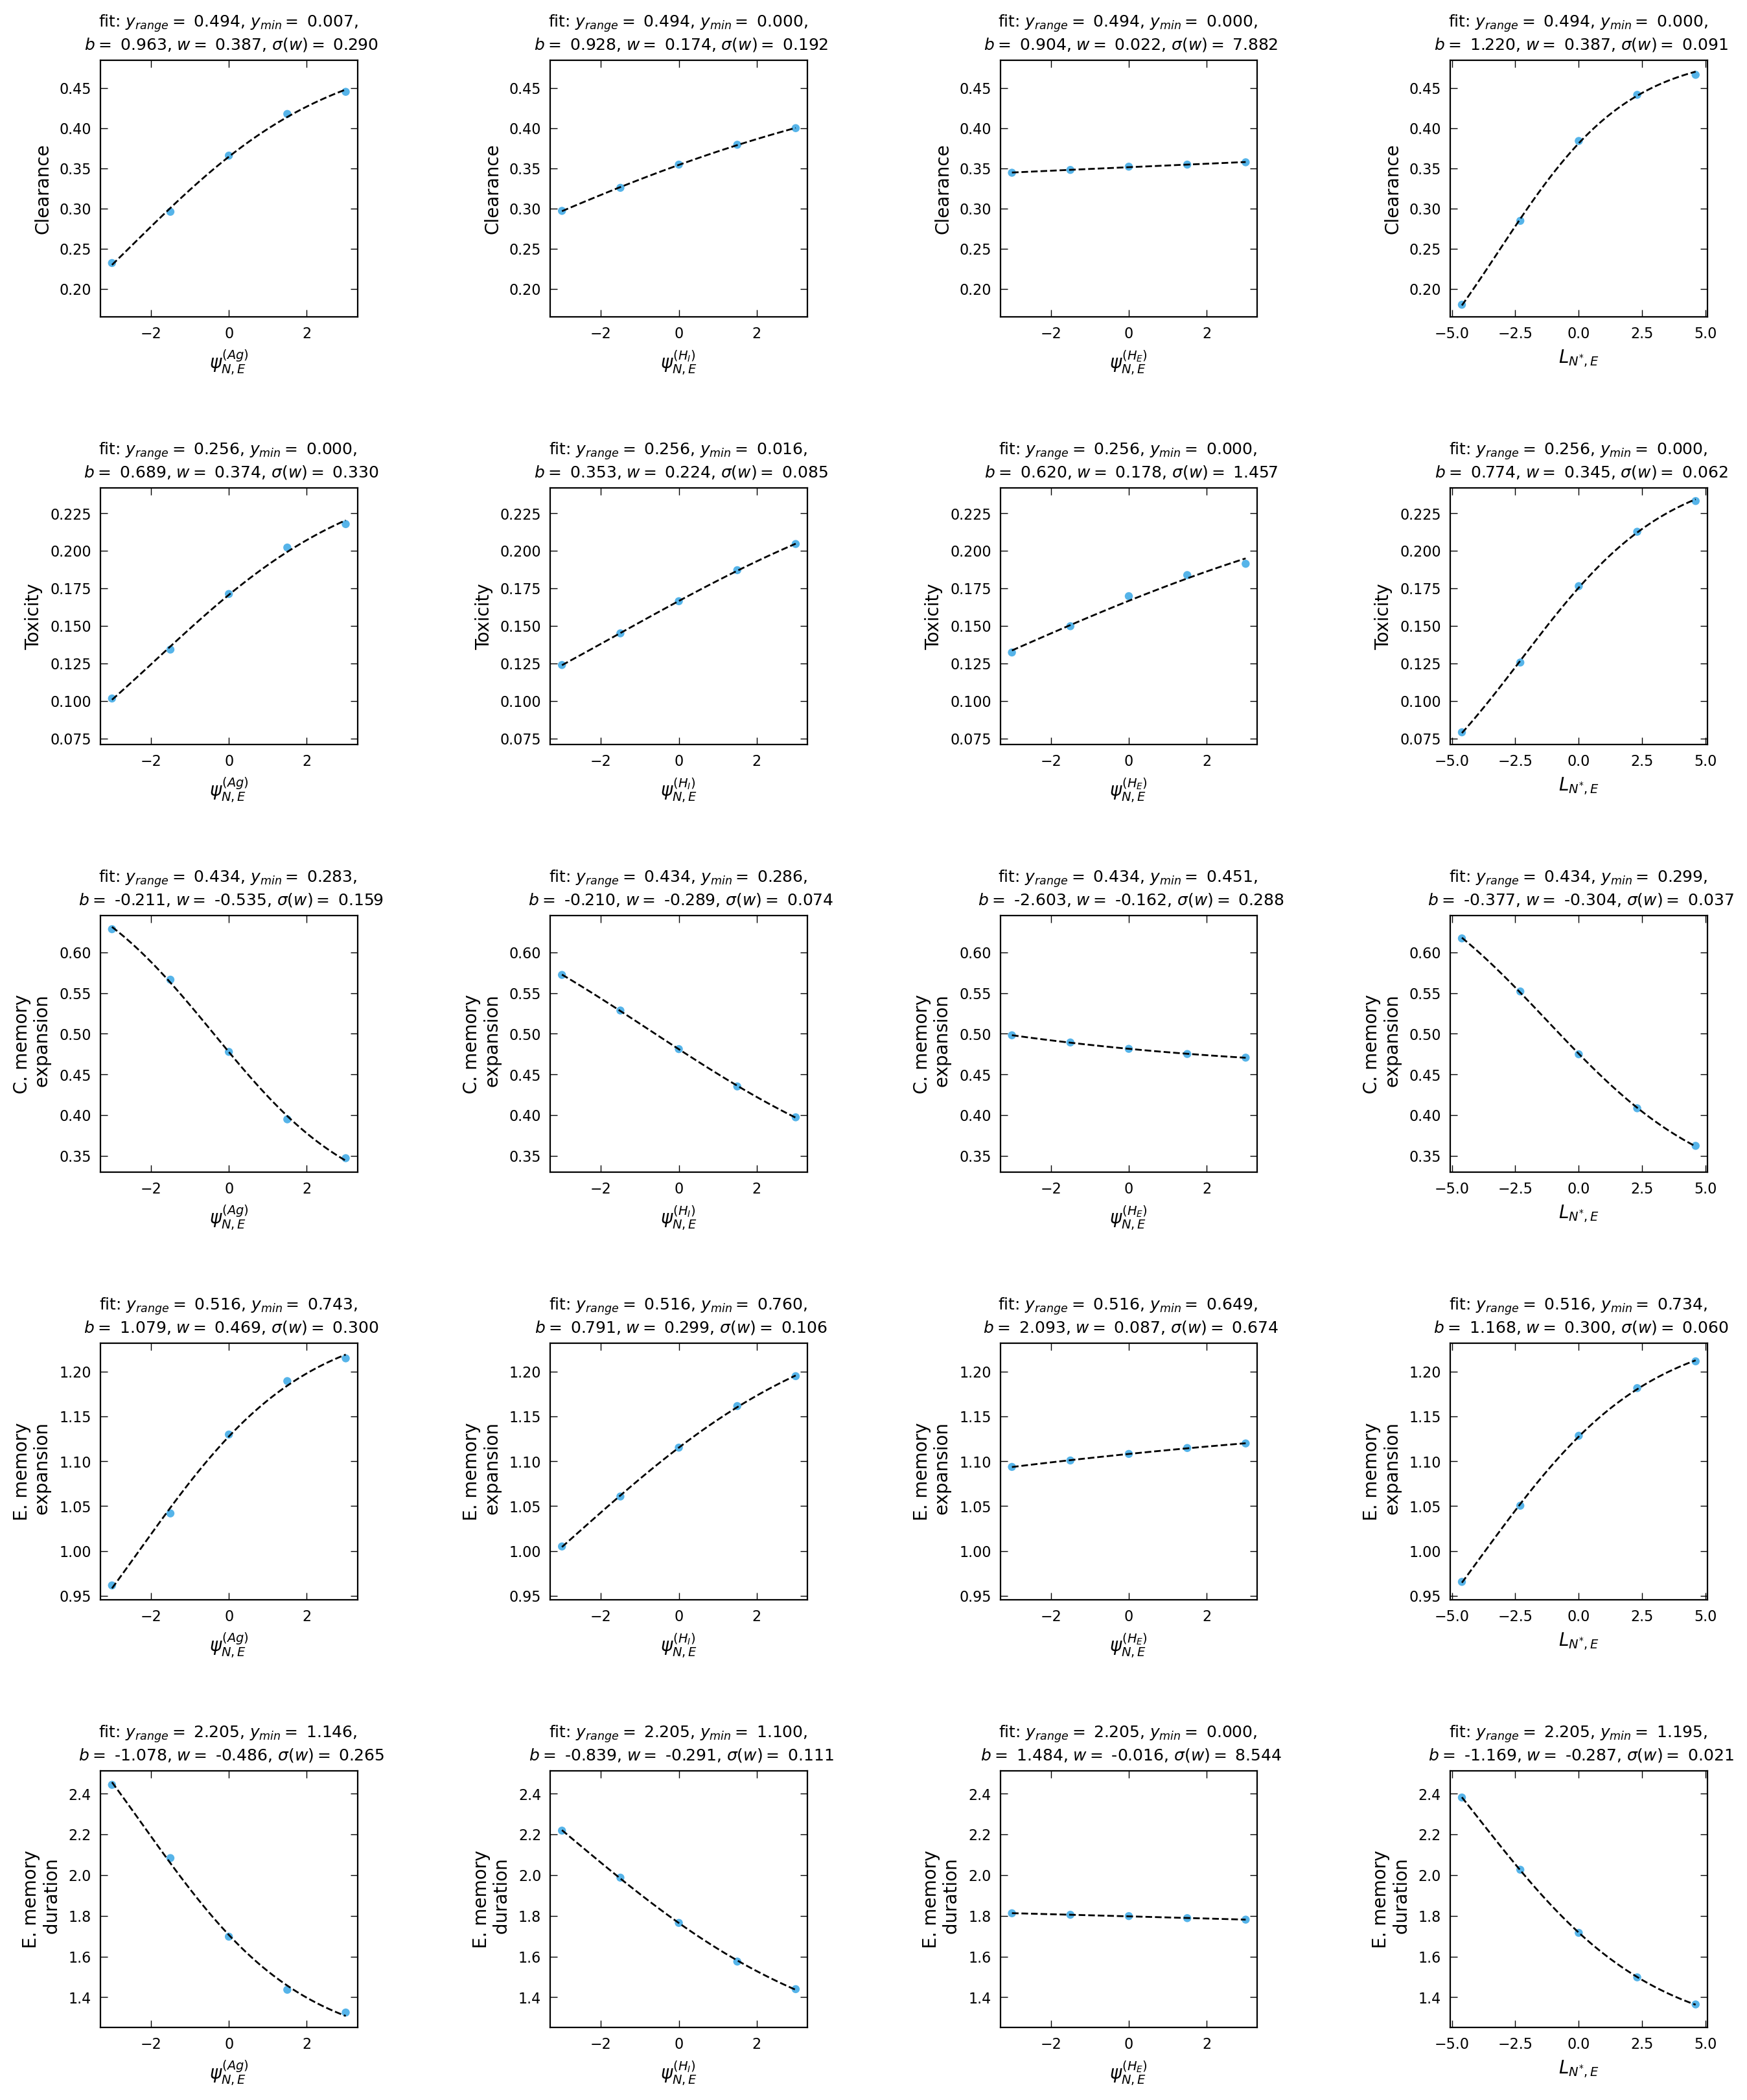

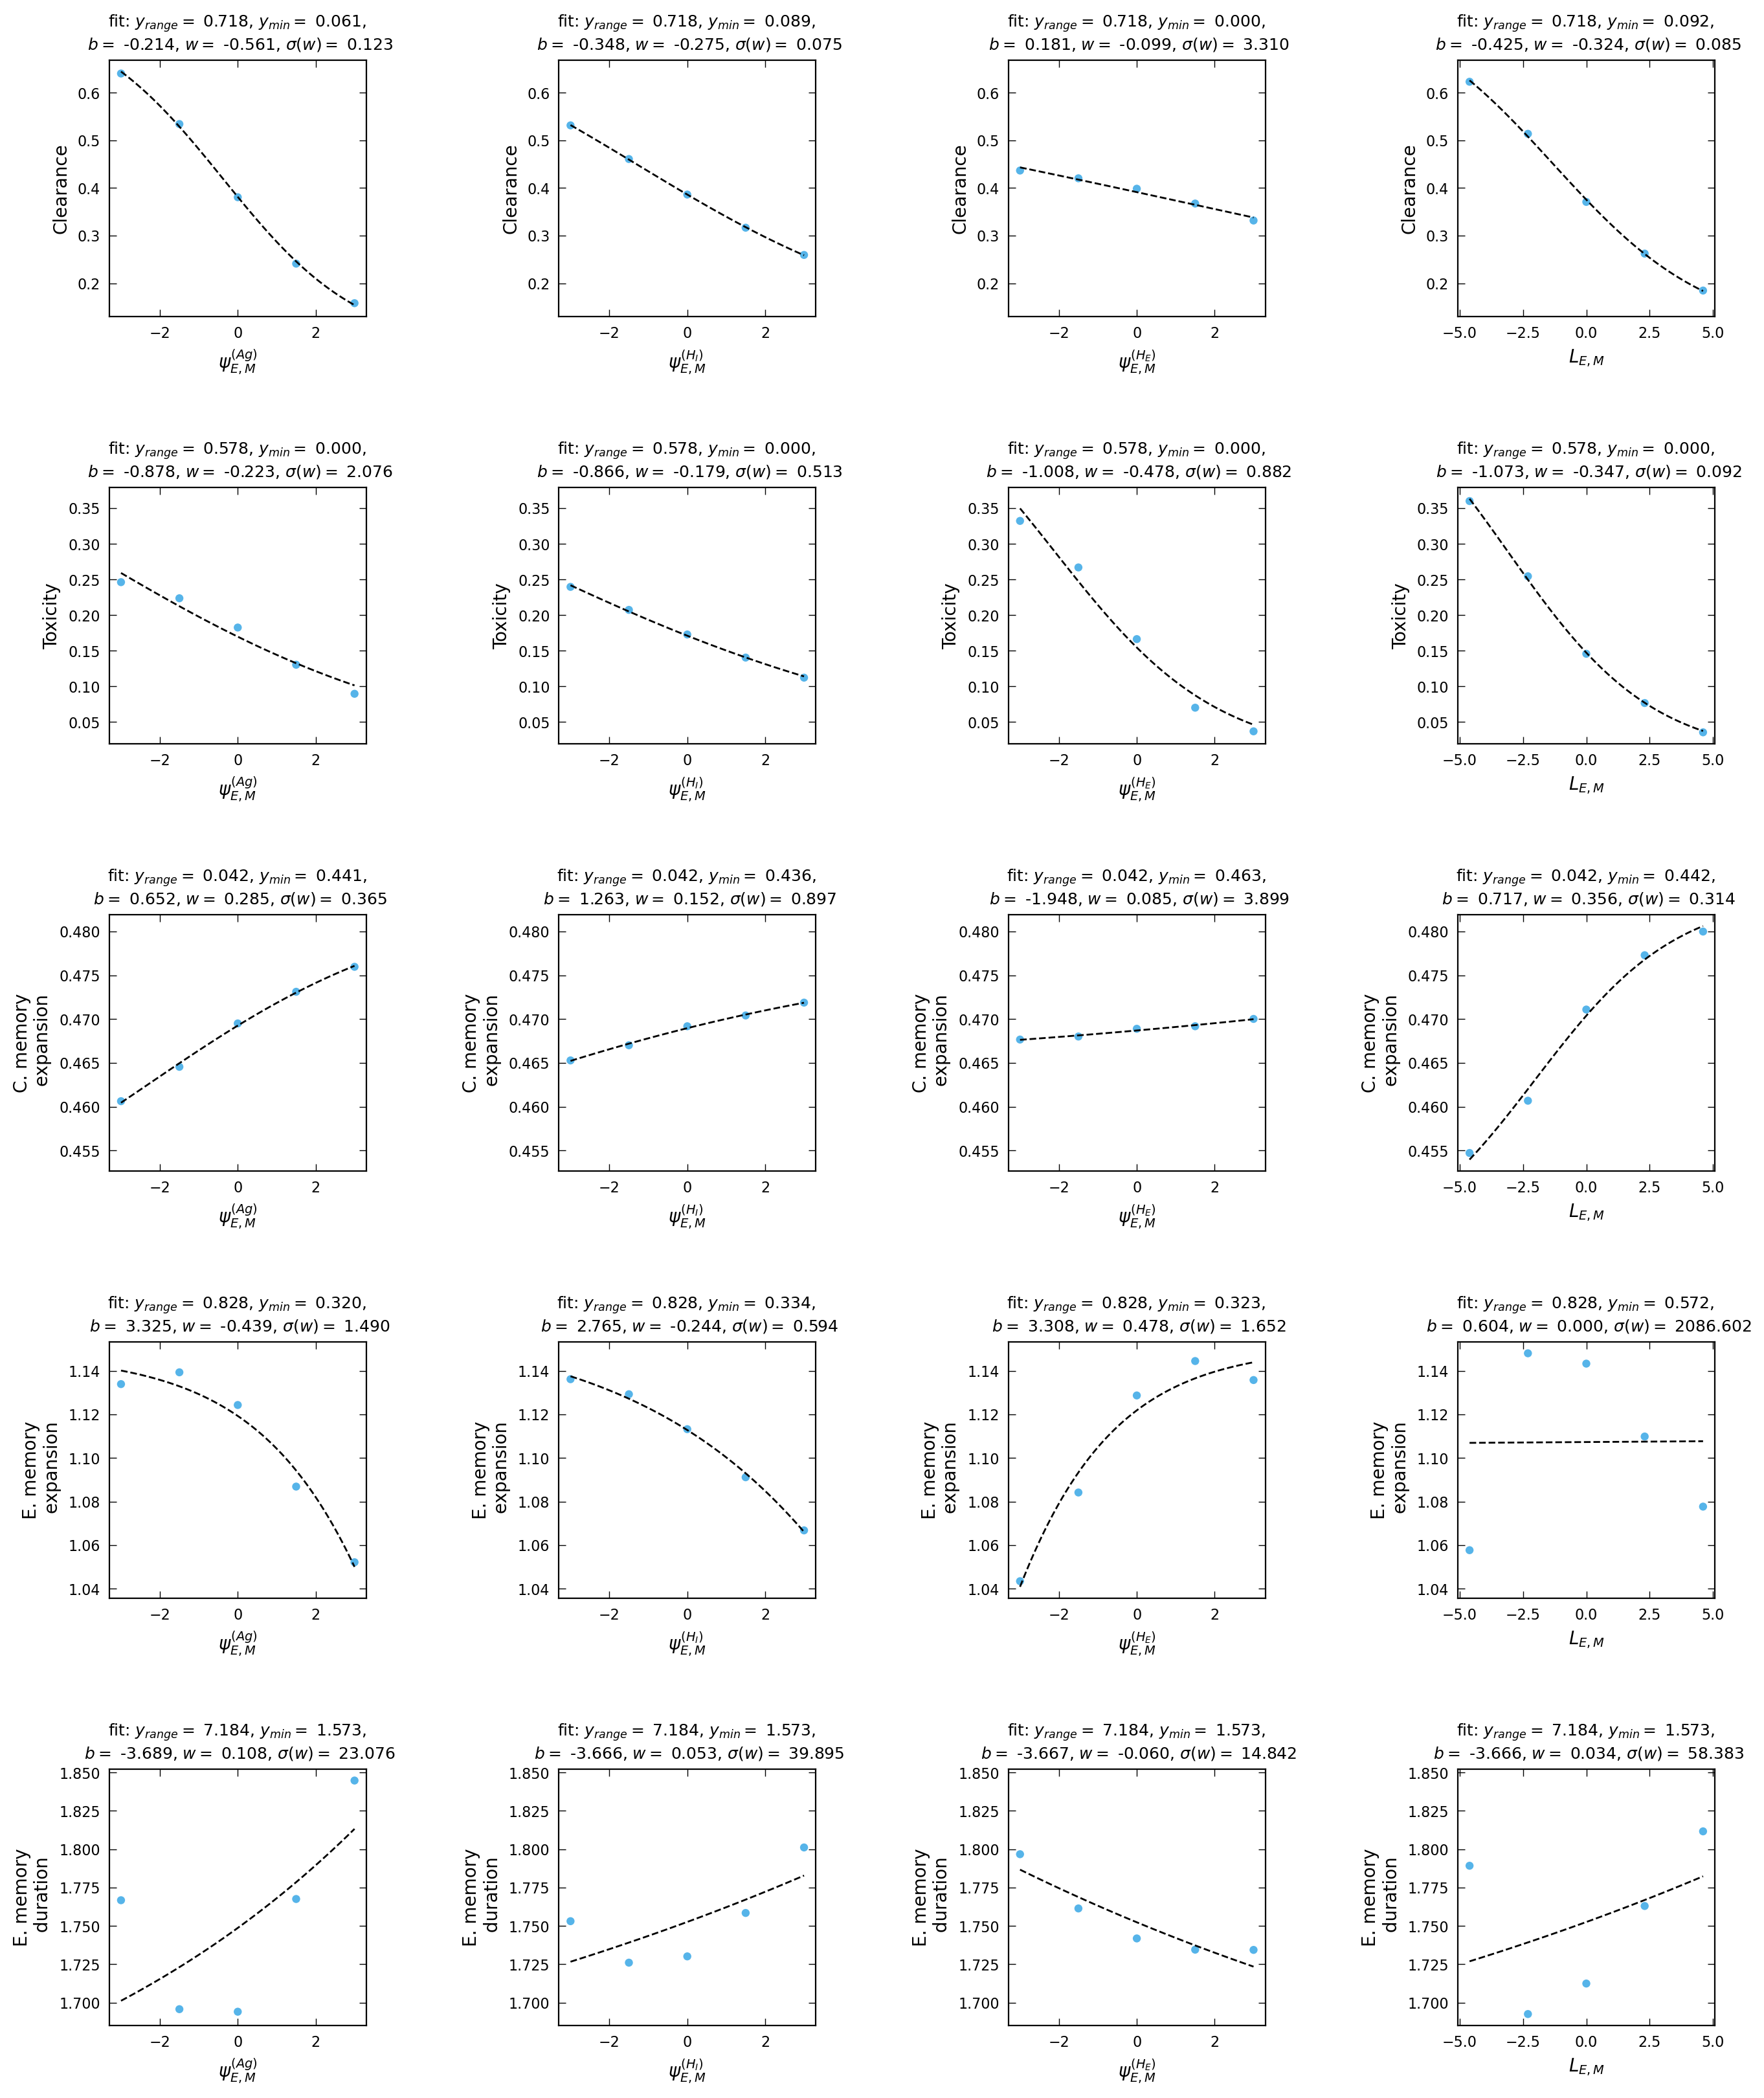

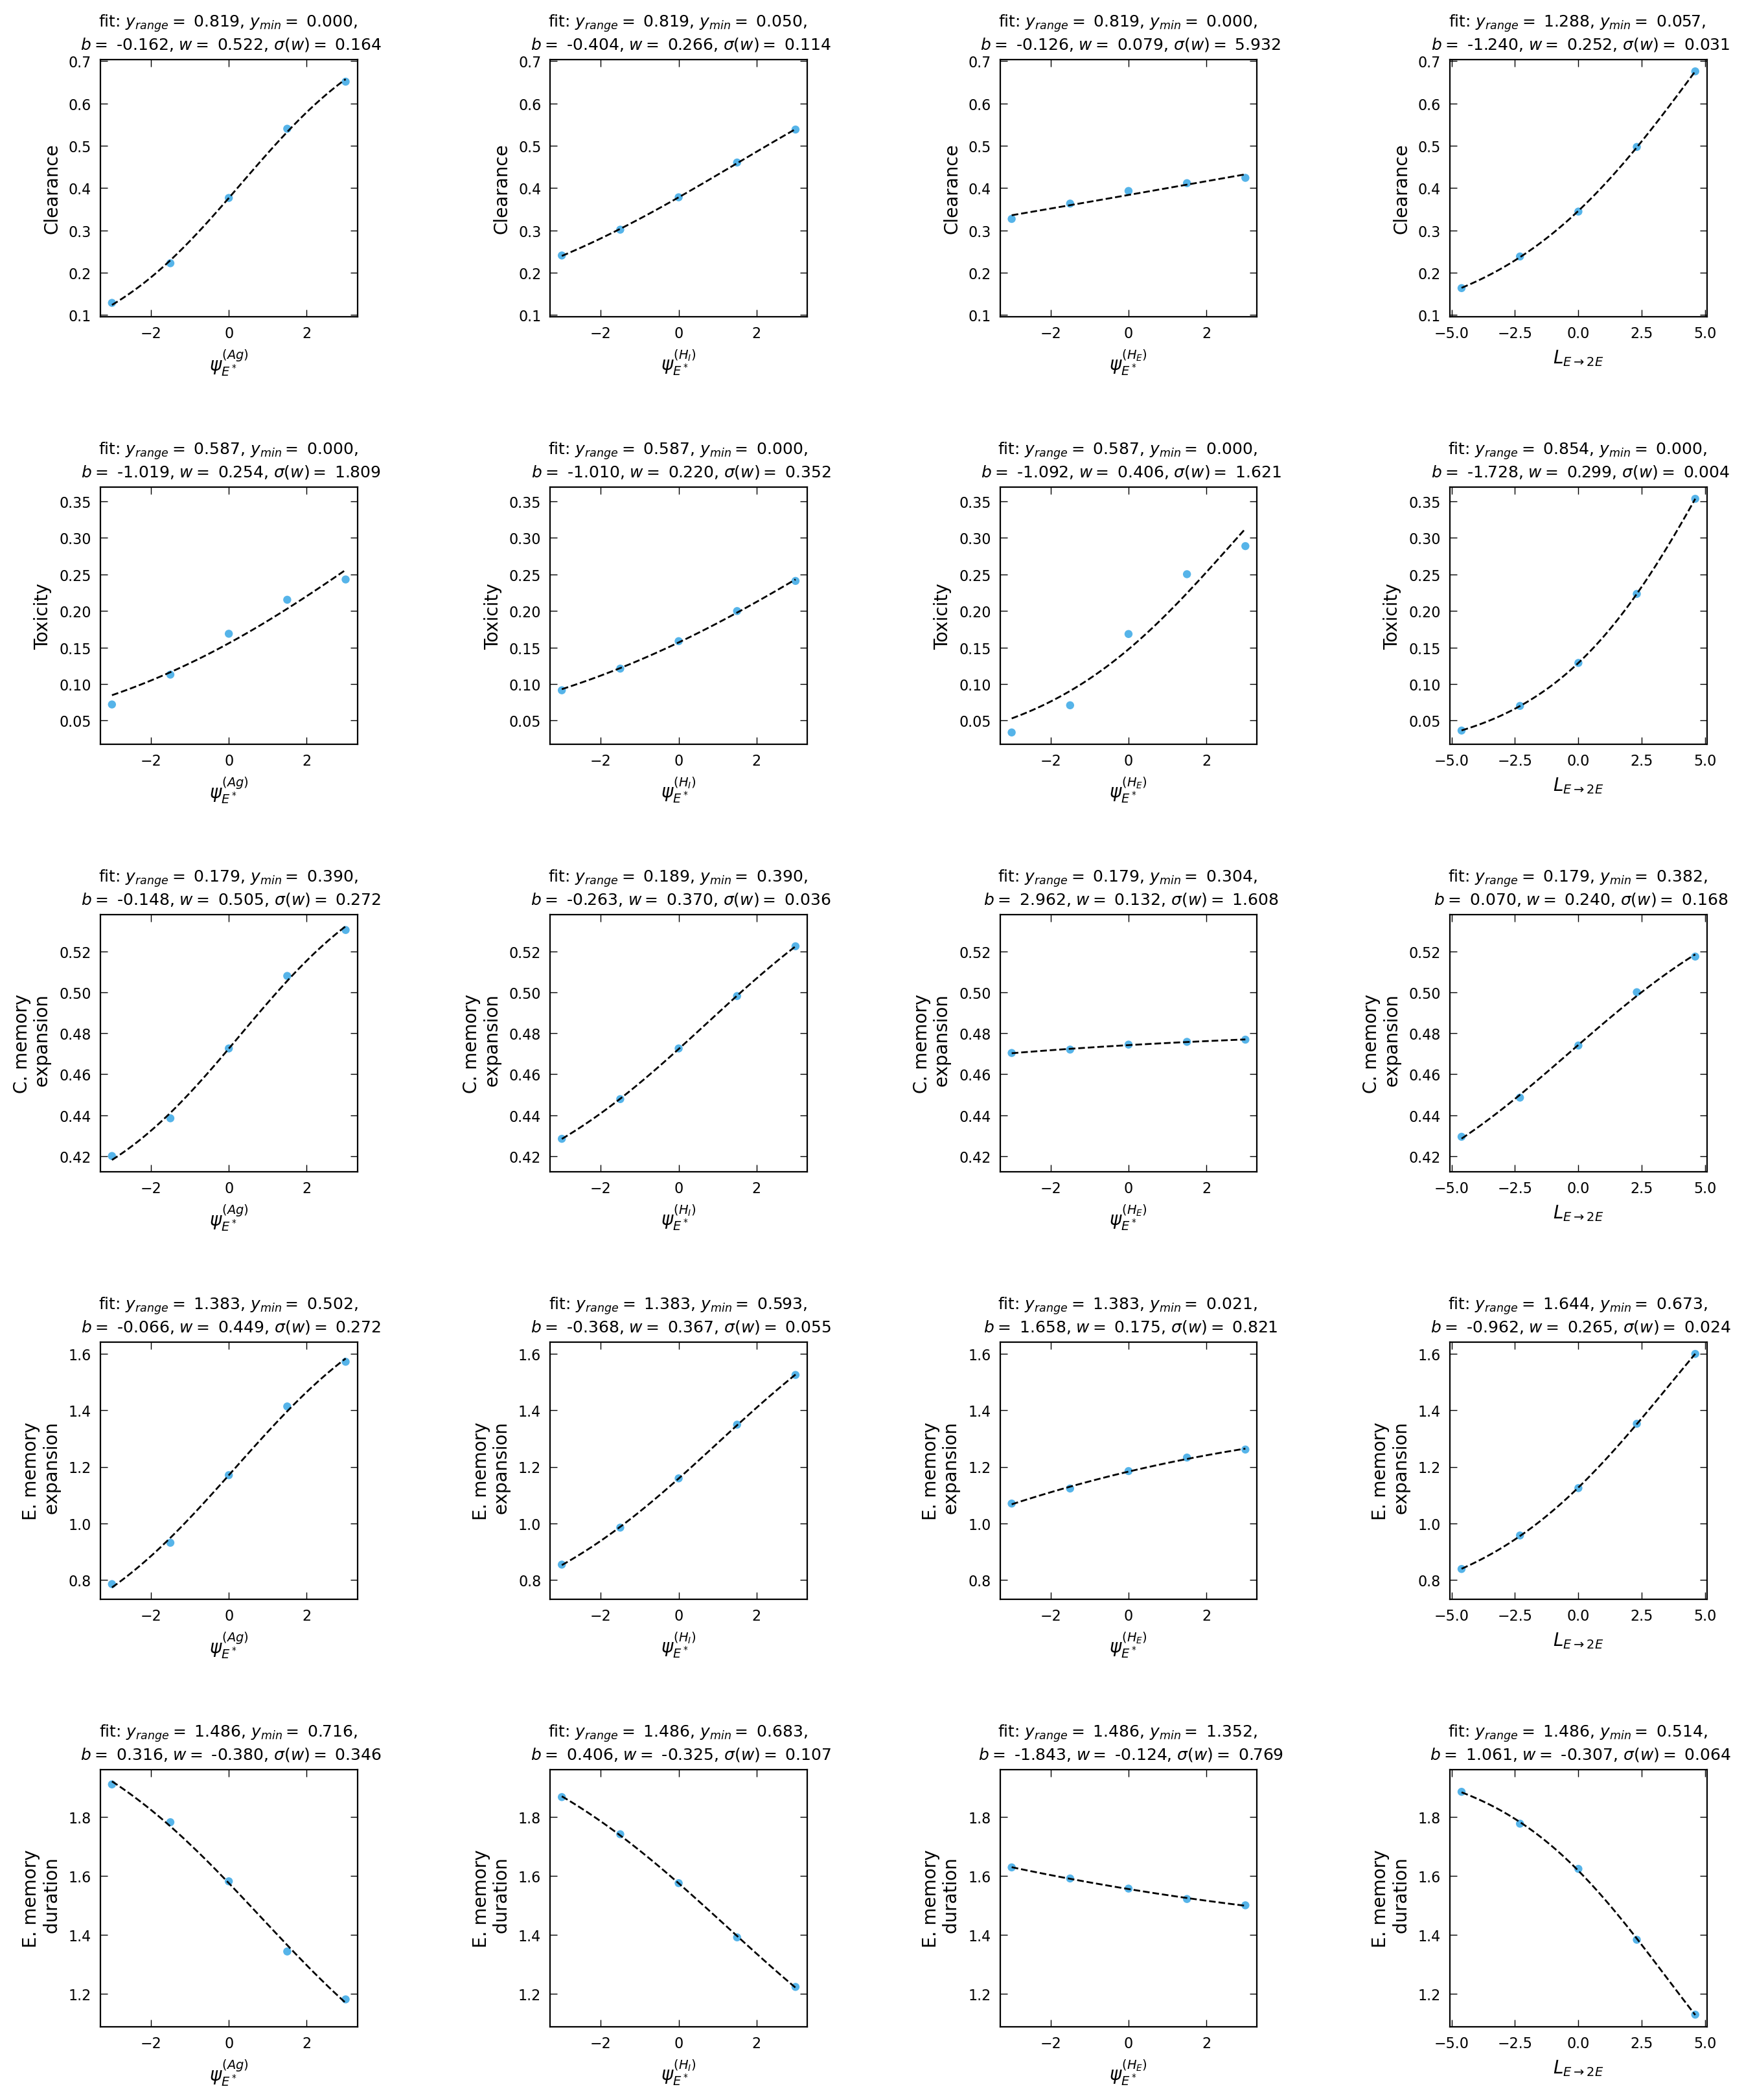

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [12]:
# Regress Performance measures on regulation parameters
num_cpu = 133
variables = reg

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min)/2, 0.0 if y_min >= 0.0 else 2*y_min] + len(variables)*[-3.0*L0_max] + num_modules*[-3.0*L0_max], 
                                     [(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.01, y_min if y_min > 0 else + y_std + 0.01] + len(variables)*[3.0*L0_max] + num_modules*[3.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [13]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [14]:
# View result
perf_choice = 2 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
2,0.827800,5.851333e-37,0.035722,0.082628,0.001141,2.116065,-0.014521,-0.027820,-0.001162,-0.319865,-0.006994,-0.001823,0.000547,-0.001421,0.020064,0.023115,-0.000224,0.369152,0.394666,2.651540,9.930478,0.939688,5.513225,0.000430,0.003470,0.003485,0.003466,0.041988,0.004911,0.004919,0.004909,0.006286,956.831661,249.583411,75.590635,194.298382,0.002081,0.002082,0.002079,0.001856,0.004167,0.033800,136857.471805,0.008723,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.260434,0.827800,0.0,0.000000,2.0,0.116692,0.288205,0.000000,0.040967,0.026400,0.003477,NaN
7,0.820055,2.355083e-34,0.036578,0.084197,0.003720,2.161997,-0.013472,-0.027315,-0.004965,-0.337291,-0.002196,0.000986,-0.002371,-0.000545,0.020146,0.024274,-0.000029,0.376288,0.394191,2.798971,10.290628,0.998410,15.032109,0.000435,0.003480,0.003496,0.003476,0.046702,0.005256,0.005262,0.005254,0.006804,1185.672378,532.545336,1280.040148,294.822871,0.002133,0.002134,0.002131,0.001894,0.004172,0.035899,539954.797775,0.008815,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.264181,0.820055,0.0,0.003647,2.0,0.118213,0.291814,0.000000,0.040967,0.026400,0.009446,NaN
12,0.814336,1.020100e-03,0.035875,0.084884,0.006799,2.266490,-0.014444,-0.027214,-0.010383,-0.345859,-0.000480,-0.001998,0.000405,-0.001672,0.020337,0.024578,0.000453,0.380264,0.394670,2.867210,10.045959,1.023447,15.782546,0.000437,0.003500,0.003516,0.003496,0.059396,0.005434,0.005439,0.005432,0.007079,214.753902,893.309229,181.488869,747.646691,0.002164,0.002165,0.002162,0.001917,0.004184,0.037041,446994.098327,0.008870,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.265595,0.814336,0.0,0.002310,2.0,0.118961,0.293185,0.000000,0.040964,0.026400,0.021598,NaN
17,0.810996,1.433411e-03,0.036114,0.085561,0.012097,2.308379,-0.013695,-0.027496,-0.018950,-0.348780,-0.000159,-0.001122,-0.000375,-0.002232,0.020533,0.024543,0.000709,0.381753,0.394707,2.890675,10.246459,1.030562,13.481699,0.000437,0.003508,0.003525,0.003504,0.065404,0.005496,0.005501,0.005497,0.007177,75.998661,526.116048,176.214539,1046.310026,0.002174,0.002175,0.002172,0.001924,0.004189,0.037457,468526.508457,0.008883,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.265544,0.810996,0.0,0.001736,2.0,0.119000,0.293105,0.000000,0.040957,0.026400,0.041822,NaN
22,0.807278,1.958694e-03,0.036811,0.086750,0.021448,2.362731,-0.013624,-0.027151,-0.032723,-0.352208,0.000567,-0.000057,0.000160,-0.004260,0.020565,0.024733,0.001215,0.383748,0.394517,2.919977,10.406540,1.040300,5.546426,0.000437,0.003521,0.003538,0.003519,0.074156,0.005578,0.005584,0.005587,0.007305,130.209241,22.323264,40.588570,967.525232,0.002189,0.002190,0.002188,0.001935,0.004199,0.038019,227270.179228,0.008907,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.265667,0.807278,0.0,0.001734,2.0,0.119216,0.293236,0.000000,0.040937,0.026400,0.071394,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,0.882335,5.458147e-03,0.225173,2.216720,0.011203,1.835690,-0.015263,-0.158882,-0.006418,-0.278990,-0.000688,0.000375,0.001226,0.002851,0.054653,0.589971,0.000607,0.519134,0.70

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

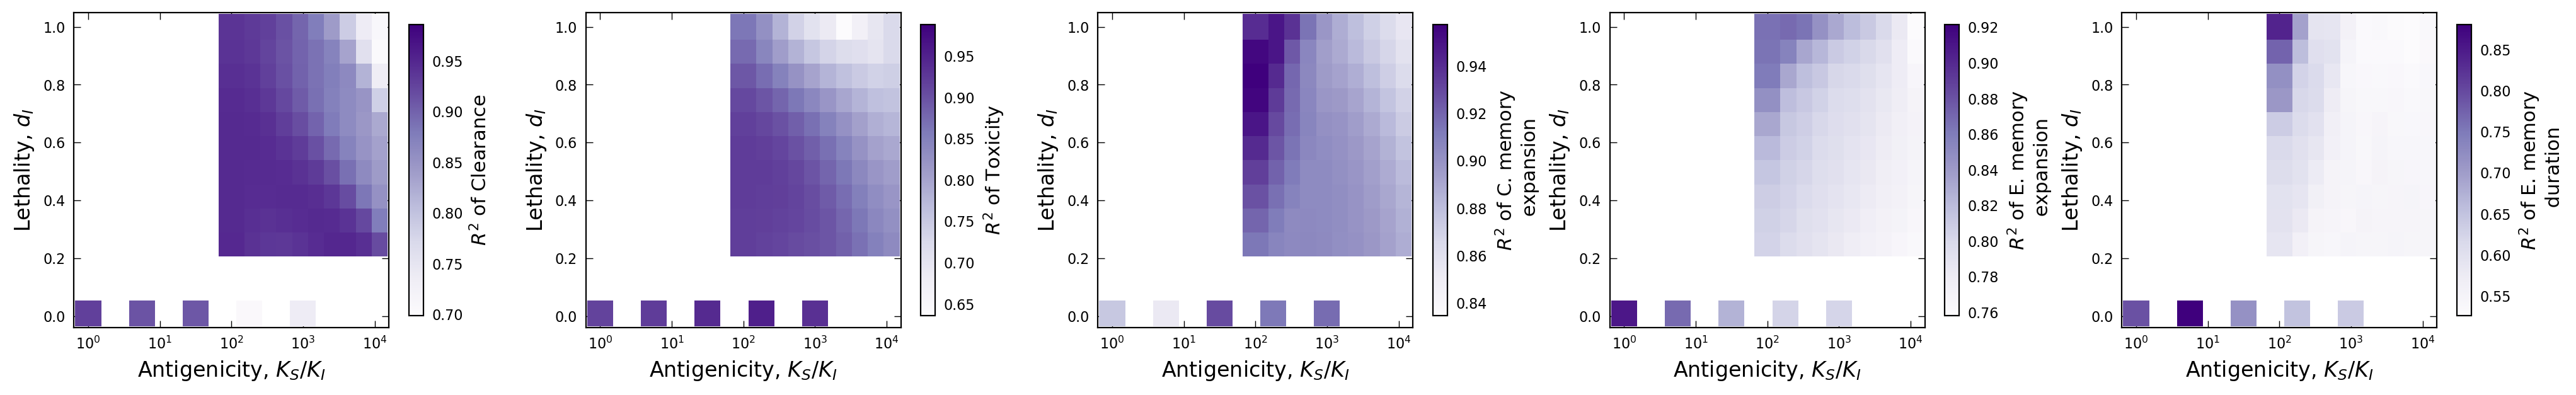

In [15]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{S}/K_{I}$", "Lethality, "+r"$d_{I}$"]
size = 2500/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_r_sq = 1 - data.rmse**2/data.y_std**2
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

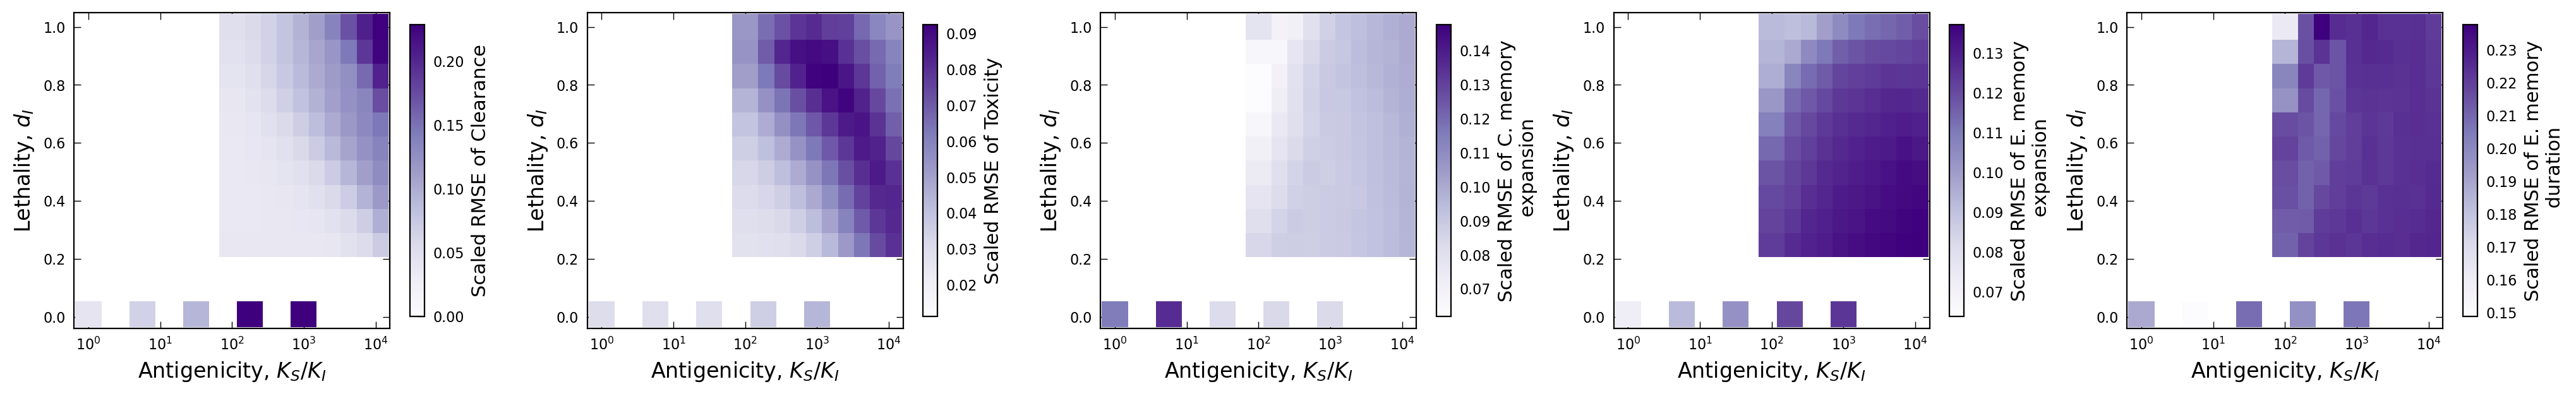

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{S}/K_{I}$", "Lethality, "+r"$d_{I}$"]
size = 2500/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_rmse_over_max = data.rmse/data.y_range
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

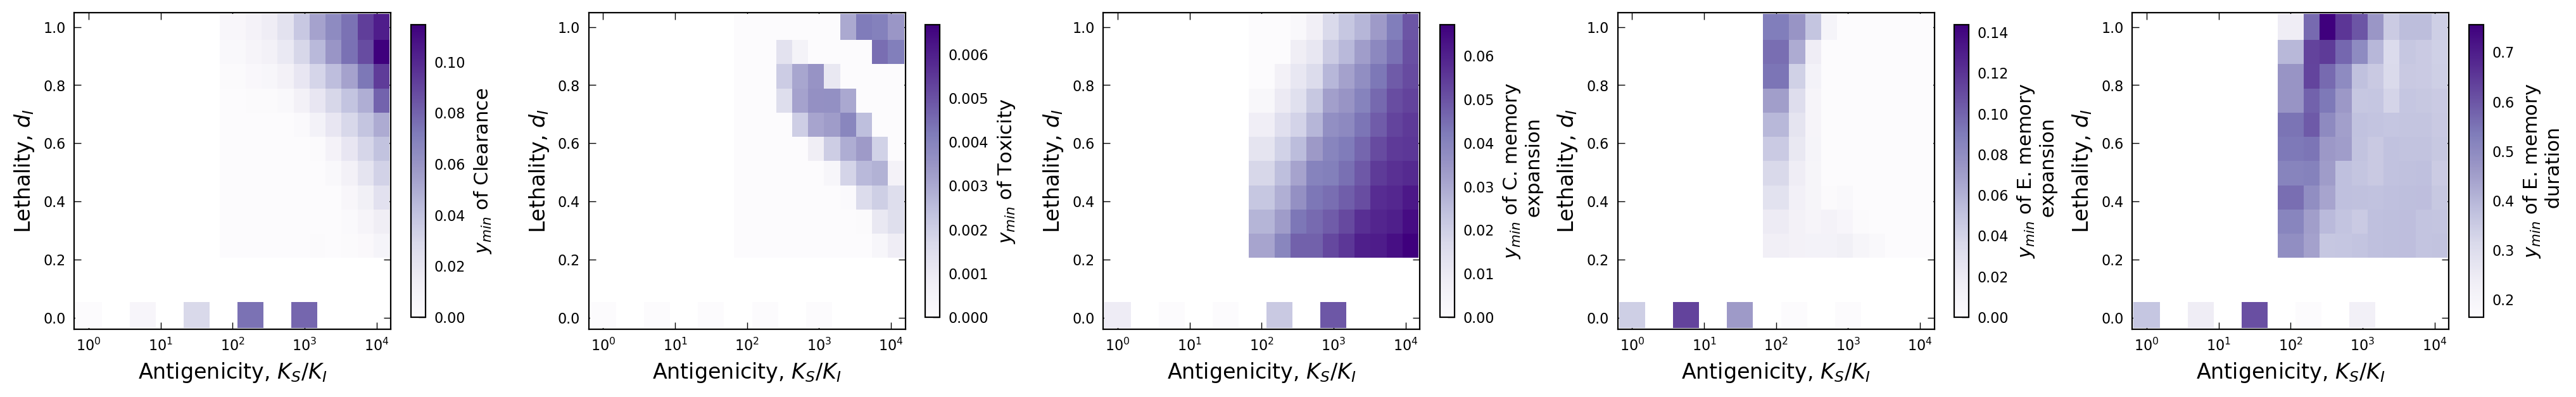

In [17]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data.y_min, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

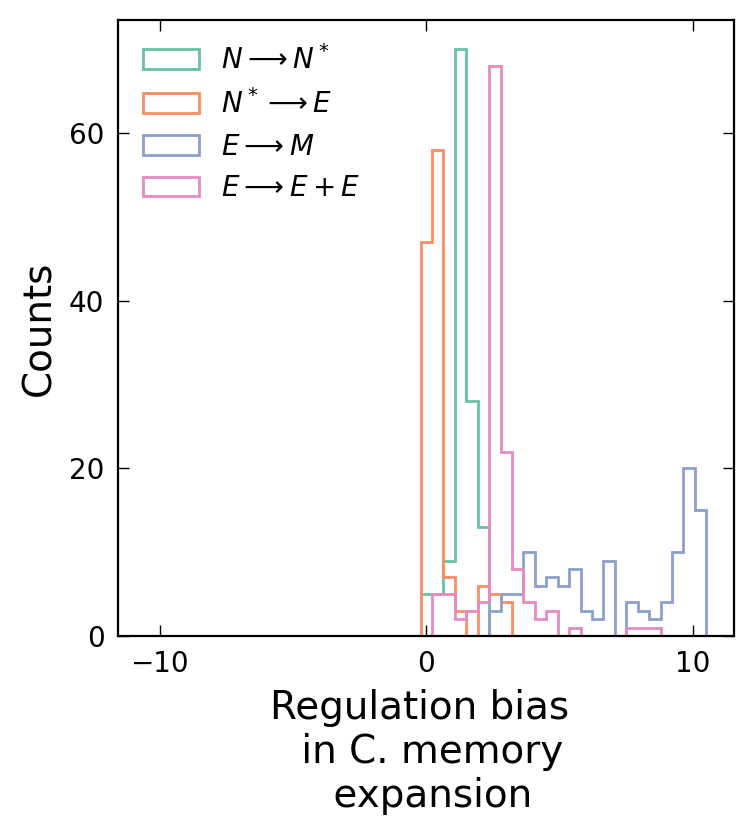

In [18]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

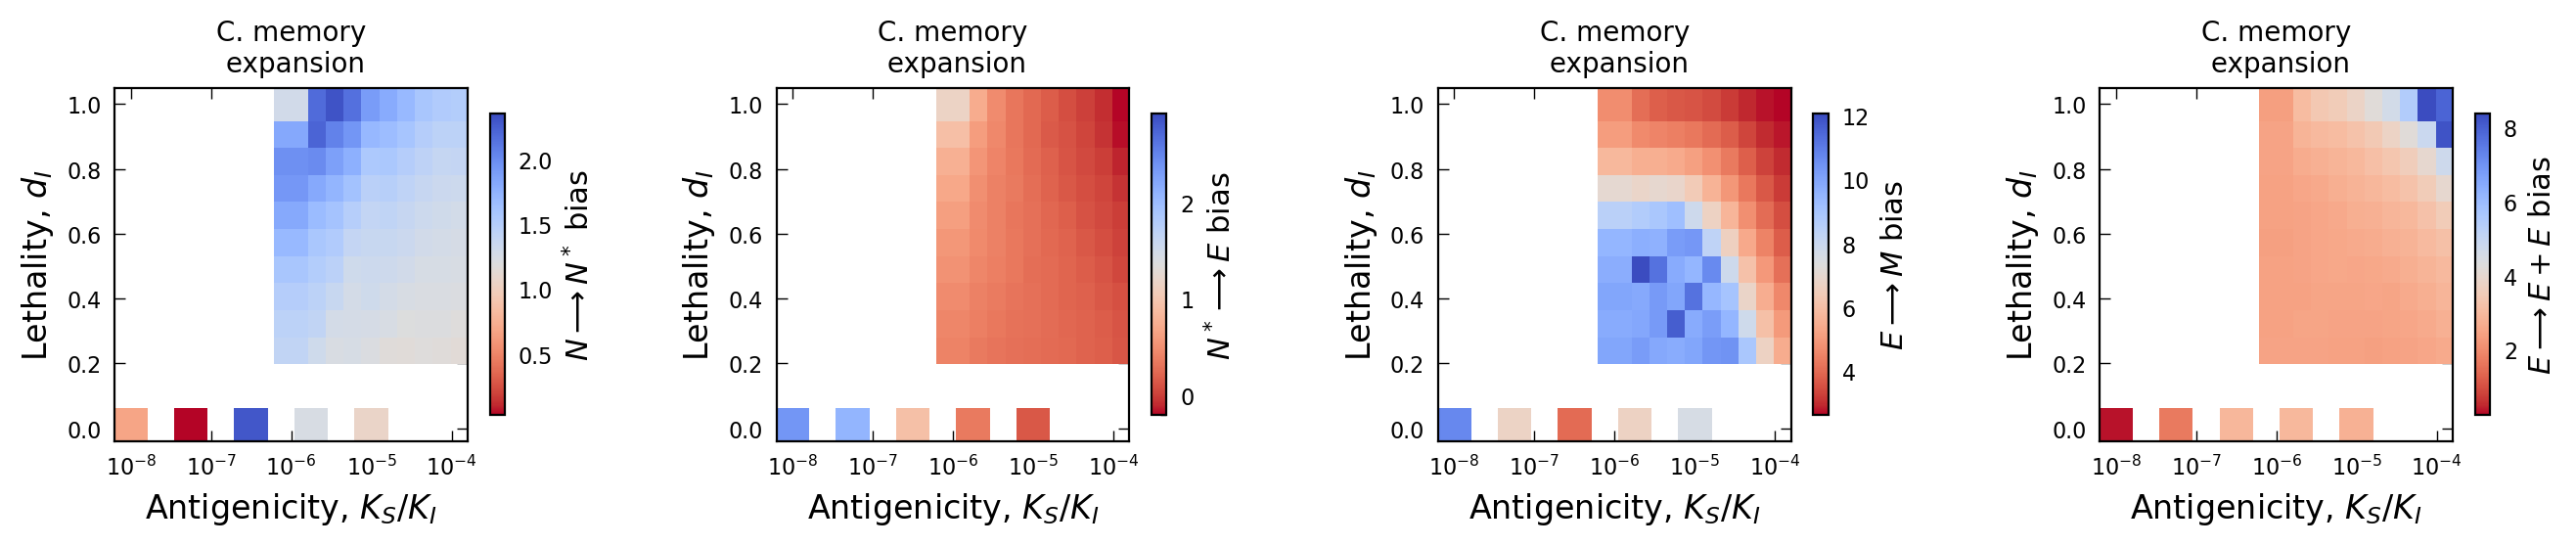

In [19]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

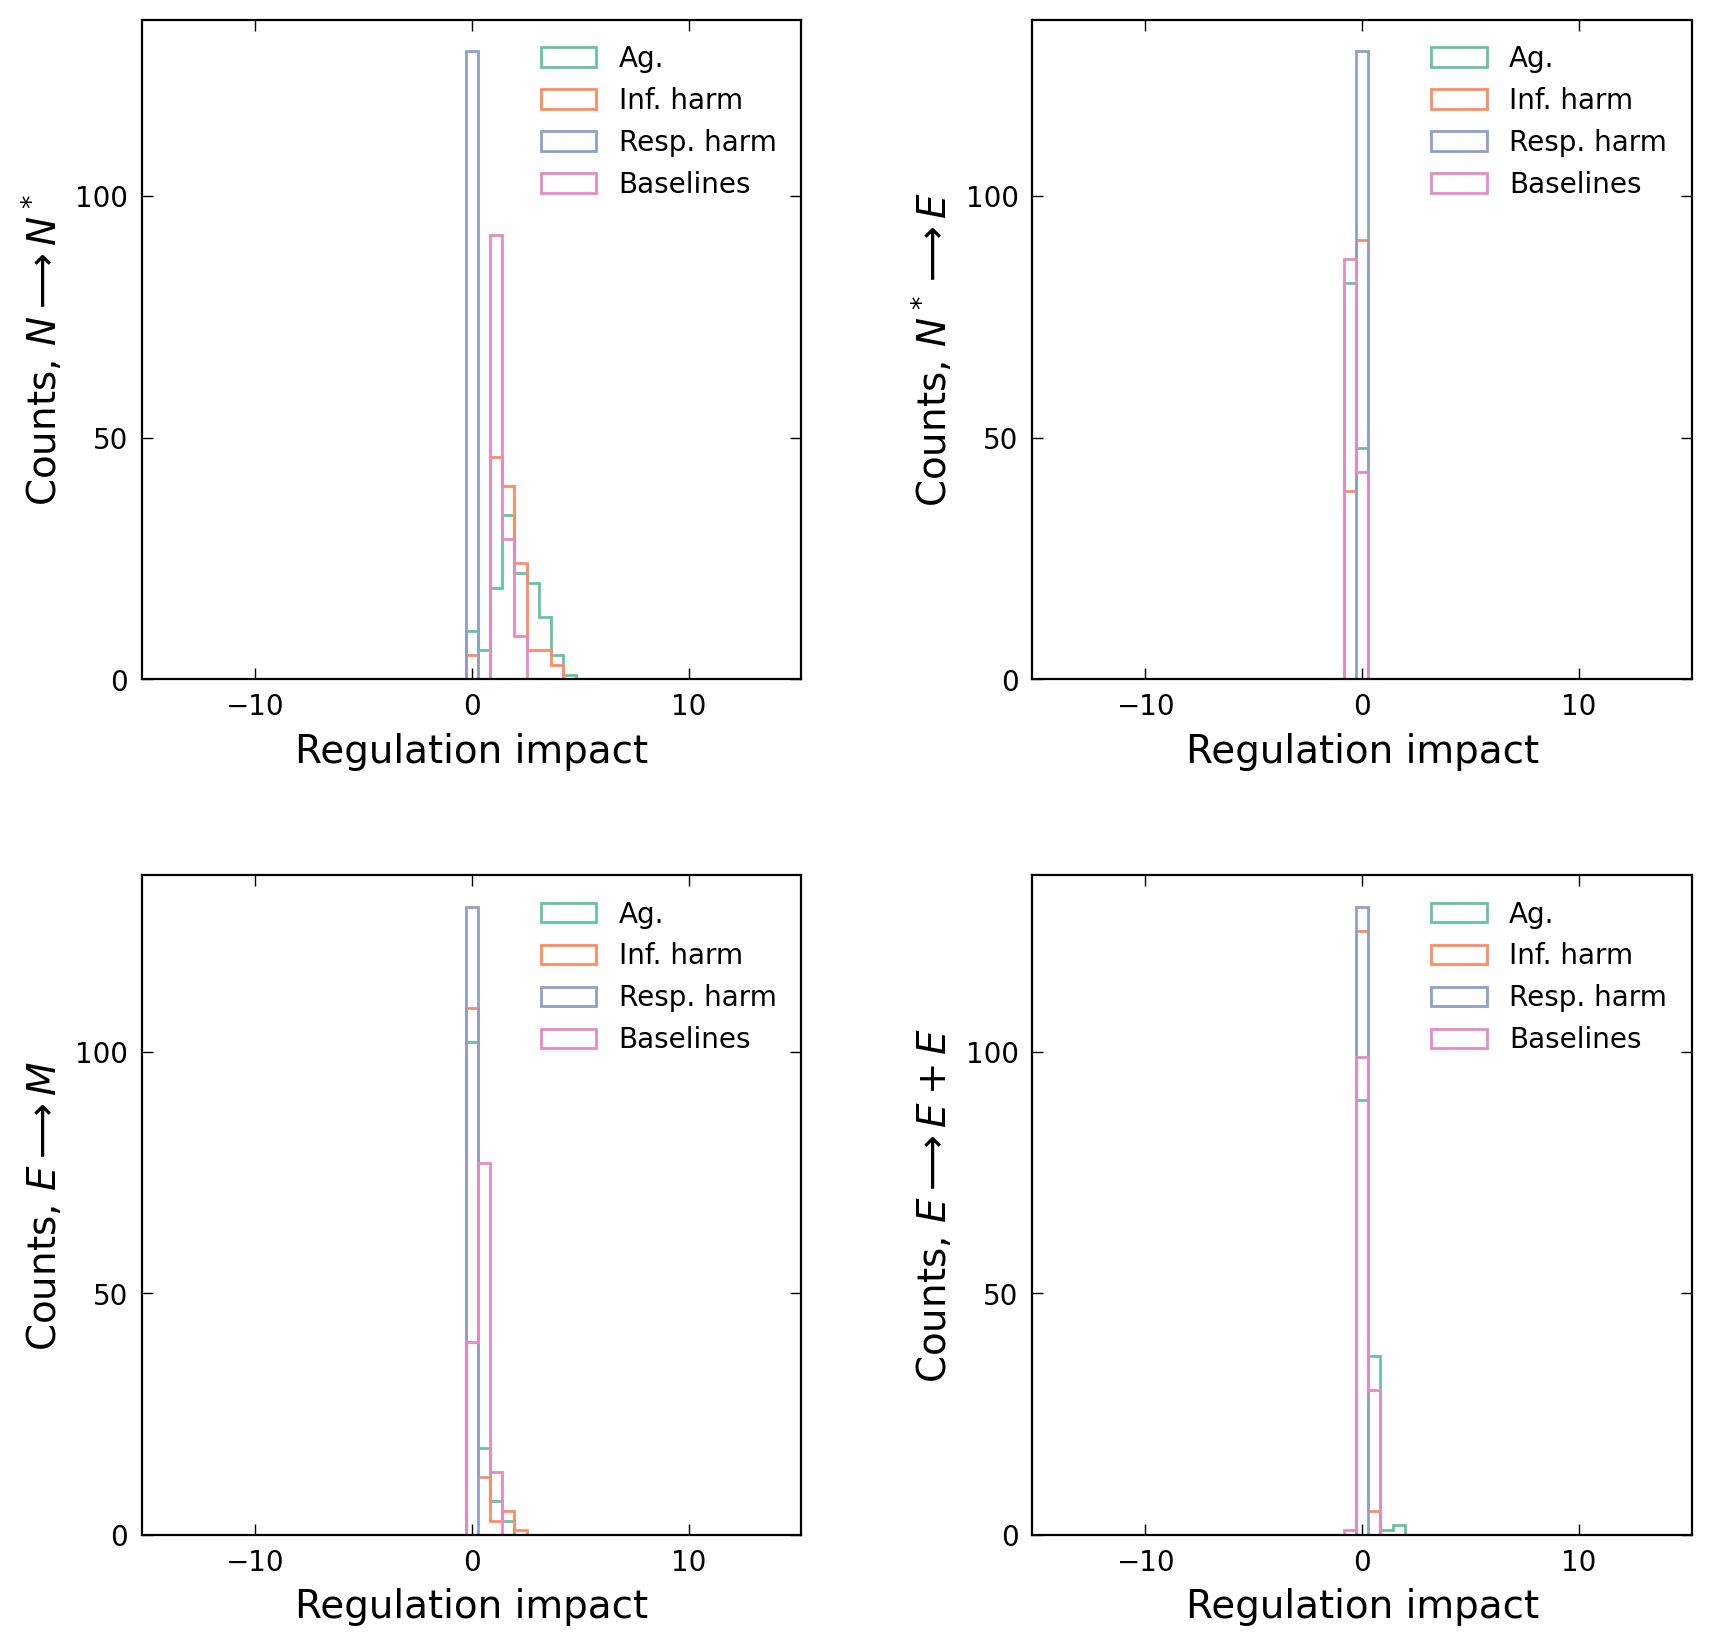

In [20]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*L0_max, 3.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
2,0.827800,5.851333e-37,0.035722,0.082628,0.001141,2.116065,-0.014521,-0.027820,-0.001162,-0.319865,-0.006994,-0.001823,0.000547,-0.001421,0.020064,0.023115,-0.000224,0.369152,0.394666,2.651540,9.930478,0.939688,5.513225,0.000430,0.003470,0.003485,0.003466,0.041988,0.004911,0.004919,0.004909,0.006286,956.831661,249.583411,75.590635,194.298382,0.002081,0.002082,0.002079,0.001856,0.004167,0.033800,136857.471805,0.008723,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.260434,0.827800,0.0,0.000000,2.0,0.116692,0.288205,0.0,0.040967,0.0264,0.003477,NaN
7,0.820055,2.355083e-34,0.036578,0.084197,0.003720,2.161997,-0.013472,-0.027315,-0.004965,-0.337291,-0.002196,0.000986,-0.002371,-0.000545,0.020146,0.024274,-0.000029,0.376288,0.394191,2.798971,10.290628,0.998410,15.032109,0.000435,0.003480,0.003496,0.003476,0.046702,0.005256,0.005262,0.005254,0.006804,1185.672378,532.545336,1280.040148,294.822871,0.002133,0.002134,0.002131,0.001894,0.004172,0.035899,539954.797775,0.008815,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.264181,0.820055,0.0,0.003647,2.0,0.118213,0.291814,0.0,0.040967,0.0264,0.009446,NaN
12,0.814336,1.020100e-03,0.035875,0.084884,0.006799,2.266490,-0.014444,-0.027214,-0.010383,-0.345859,-0.000480,-0.001998,0.000405,-0.001672,0.020337,0.024578,0.000453,0.380264,0.394670,2.867210,10.045959,1.023447,15.782546,0.000437,0.003500,0.003516,0.003496,0.059396,0.005434,0.005439,0.005432,0.007079,214.753902,893.309229,181.488869,747.646691,0.002164,0.002165,0.002162,0.001917,0.004184,0.037041,446994.098327,0.008870,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.265595,0.814336,0.0,0.002310,2.0,0.118961,0.293185,0.0,0.040964,0.0264,0.021598,NaN
17,0.810996,1.433411e-03,0.036114,0.085561,0.012097,2.308379,-0.013695,-0.027496,-0.018950,-0.348780,-0.000159,-0.001122,-0.000375,-0.002232,0.020533,0.024543,0.000709,0.381753,0.394707,2.890675,10.246459,1.030562,13.481699,0.000437,0.003508,0.003525,0.003504,0.065404,0.005496,0.005501,0.005497,0.007177,75.998661,526.116048,176.214539,1046.310026,0.002174,0.002175,0.002172,0.001924,0.004189,0.037457,468526.508457,0.008883,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.265544,0.810996,0.0,0.001736,2.0,0.119000,0.293105,0.0,0.040957,0.0264,0.041822,NaN
22,0.807278,1.958694e-03,0.036811,0.086750,0.021448,2.362731,-0.013624,-0.027151,-0.032723,-0.352208,0.000567,-0.000057,0.000160,-0.004260,0.020565,0.024733,0.001215,0.383748,0.394517,2.919977,10.406540,1.040300,5.546426,0.000437,0.003521,0.003538,0.003519,0.074156,0.005578,0.005584,0.005587,0.007305,130.209241,22.323264,40.588570,967.525232,0.002189,0.002190,0.002188,0.001935,0.004199,0.038019,227270.179228,0.008907,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.265667,0.807278,0.0,0.001734,2.0,0.119216,0.293236,0.0,0.040937,0.0264,0.071394,NaN


In [22]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
527,1.796389,4.126935e-02,3.079045,1.009790,0.031528,1.064069,-0.780222,-0.216992,-0.024133,-0.333420,0.186498,0.054767,0.044219,0.070046,0.287201,0.062435,0.002192,0.220991,1.055264,0.176413,10.419512,2.233454,0.010880,0.000566,0.009246,0.004387,0.003112,0.002748,0.002441,0.001469,0.001333,0.000834,28.619190,12.222790,11.490305,12.507113,0.003833,0.002819,0.002765,0.003101,0.004196,0.003679,192.412522,0.020704,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,0.526430,1.796389,0.0,0.448191,2.0,0.146023,0.494222,2.651569,1.377820,0.449806,0.045561,-6.698971
532,1.759934,4.446470e-02,3.107875,1.017118,0.052696,1.081000,-0.783034,-0.217151,-0.039216,-0.336437,0.504296,0.158856,0.043050,0.146843,0.289982,0.062844,0.005611,0.237423,1.070314,0.202019,9.858407,2.405033,0.004107,0.000560,0.009218,0.004367,0.003101,0.002765,0.002434,0.001467,0.001336,0.000838,5.163359,2.613376,2.244351,2.148850,0.003964,0.003036,0.002986,0.003412,0.004186,0.003668,21.799633,0.021753,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,0.531003,1.759934,0.0,0.454995,2.0,0.145047,0.496621,2.651569,1.339527,0.431629,0.070631,-6.698971
537,1.722864,4.733729e-02,3.131827,1.021934,0.084131,1.097849,-0.787702,-0.217225,-0.064030,-0.341041,1.355876,0.055210,0.047937,0.217279,0.289379,0.062168,0.010245,0.252257,1.072907,0.212523,9.976987,2.569147,0.003389,0.000555,0.009273,0.004387,0.003125,0.002813,0.002448,0.001478,0.001356,0.000849,1.997892,0.199126,0.198248,0.212068,0.004167,0.003301,0.003256,0.003807,0.004194,0.003668,6.183350,0.023413,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,0.530439,1.722864,0.0,0.455353,2.0,0.144558,0.496375,2.651569,1.292889,0.411249,0.113424,-6.698971
542,1.701427,4.805599e-02,3.143810,1.021549,0.129933,1.112439,-0.783713,-0.212178,-0.104480,-0.345613,0.561430,0.037817,0.035065,0.904894,0.281883,0.059986,0.017737,0.260223,1.064505,0.199580,9.746527,2.685666,0.003248,0.000545,0.009250,0.004370,0.003138,0.002844,0.002417,0.001462,0.001368,0.000851,0.113772,0.083556,0.083474,0.548486,0.004343,0.003520,0.003481,0.004163,0.004155,0.003619,2.587090,0.025128,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,0.525514,1.701427,0.0,0.449111,2.0,0.142984,0.494310,2.651569,1.202464,0.364280,0.181288,-6.698971
547,1.691153,4.919336e-02,3.156053,1.018495,0.195145,1.131977,-0.790062,-0.209976,-0.153956,-0.355798,0.371968,0.049646,0.038526,0.678164,0.267611,0.056820,0.030897,0.264396,1.055980,0.134957,7.553954,2.785571,0.003230,0.000529,0.009245,0.004358,0.003184,0.002894,0.002389,0.001446,0.001392,0.000852,0.046537,0.042826,0.042667,0.145694,0.004565,0.003778,0.003749,0.004584,0.004130,0.003478,0.696568,0.027369,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,0.514346,1.691153,0.0,0.431589,2.0,0.140865,0.490664,2.651569,1.073314,0.308742,0.266061,-6.698971
552,1.657375,1.326006e-02,1.548830,0.987575,0.028583,1.054018,-0.322905,-0.206775,-0.019143,-0.288990,0.094461,0.057758,0.047404,0.063622,0.183661,0.112204,0.003851,0.254872,1.250541,0.375769,9.975494,2.340360,0.016278,0.000601,0.004526,0.003458,0.002309,0.002616,0.001474,0.001260,0.001083,0.000907,17.831714,11.899192,10.447619,12.694821,0.003104,0.002864,0.002715,0.003288,0.004299,0.005030,209.824825,0.019933,0.01,5.623413e+05,0.1,50000.0